In [1]:
import multiprocessing
multiprocessing.cpu_count()

12

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import corner
import pandas as pd
from lmfit import minimize, Parameters
import os
import sys
magePath = '/home/benjamin/Documents/analogs/'
os.sys.path.append(magePath)
from magE.functions import air, gaussian
from magE.directMethod import directT, run_all

In [3]:
# Read data
dataPath = '/home/benjamin/Documents/analogs/specs/'
spec = pd.read_csv(dataPath + 'j0240-0828.csv', dtype=np.float64)
wl, flux, noise = spec.T.to_numpy()
flux = flux * 1e14
noise = noise * 1e14

In [6]:
np.log10(wl)

array([3.55630433, 3.55635043, 3.55639652, ..., 3.90298608, 3.90303217,
       3.90307827])

<ErrorbarContainer object of 3 artists>

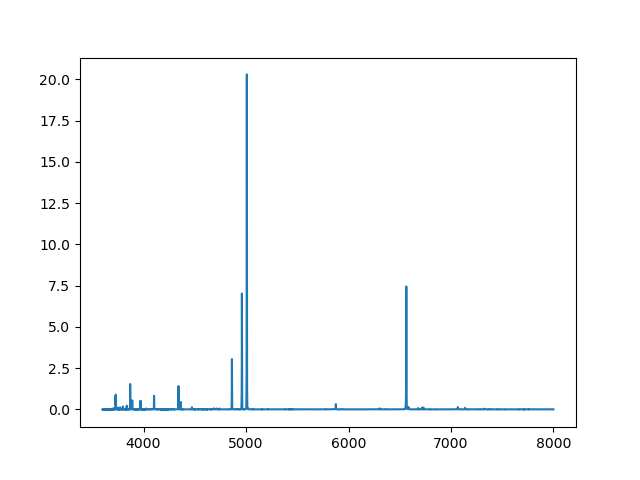

In [4]:
%matplotlib widget
plt.errorbar(wl, flux, noise)

# Low ionization lines

## [NII]$\lambda$6548 + H$\alpha$ + [NII]$\lambda$6584

In [4]:
ha_mask = (wl > 6530) & (wl < 6600)
wl_ha = wl[ha_mask]
flux_ha = flux[ha_mask]
noise_ha = noise[ha_mask]

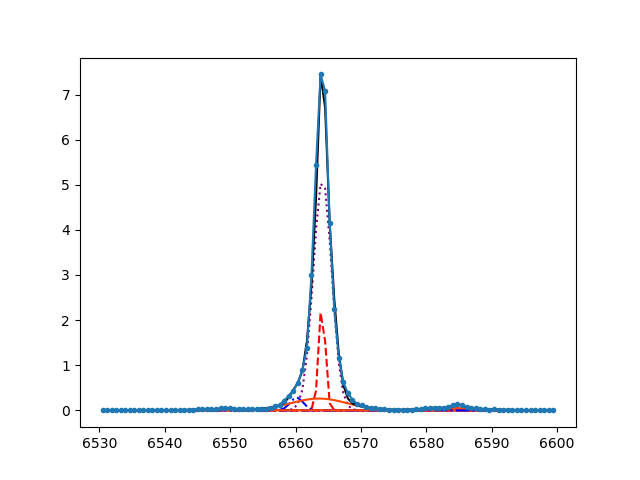

In [6]:
# Search for good initial guess
%matplotlib widget
plt.errorbar(wl_ha, flux_ha, noise_ha,
             marker='o', markersize=3, label='data')

# air
ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

# narrow and broad

ha_nar = gaussian(wl_ha, 3, ha_wav, z=1.9e-04, sigma=0.5)
ha_mid = gaussian(wl_ha, 18, ha_wav, z=2.0e-04, sigma=1.4)
ha_out = gaussian(wl_ha, 0.7, ha_wav, z=-4e-04, sigma=1.)
ha_brd = gaussian(wl_ha, 2.8, ha_wav, z=1.1966e-04, sigma=4.3)

niib_nar = gaussian(wl_ha, 0.07/3, niib_wav, z=1.9e-04, sigma=0.5)
niib_mid = gaussian(wl_ha, 0.12/3, niib_wav, z=2.0e-04, sigma=1.4)
niib_out = gaussian(wl_ha, 0.05/3, niib_wav, z=-4e-04, sigma=1.)
niib_brd = gaussian(wl_ha, 0.5/3, niib_wav, z=1.1966e-04, sigma=4.3)

niia_nar = gaussian(wl_ha, 0.07, niia_wav, z=1.9e-04, sigma=0.5)
niia_mid = gaussian(wl_ha, 0.12, niia_wav, z=2.1e-04, sigma=1.4)
niia_out = gaussian(wl_ha, 0.05, niia_wav, z=-4e-04, sigma=1.)
niia_brd = gaussian(wl_ha, 0.5, niia_wav, z=1.1966e-04, sigma=4.3)

# total
ha = ha_nar + ha_mid + ha_out + ha_brd
niib = niib_nar + niib_mid + niib_out + niib_brd
niia = niia_nar + niia_mid + niia_out + niia_brd

plt.plot(wl_ha, ha_nar, color='red', ls='--')
plt.plot(wl_ha, ha_mid, color='purple', ls=':')
plt.plot(wl_ha, ha_out, color='blue', ls='-.')
plt.plot(wl_ha, ha_brd, color='orangered')

plt.plot(wl_ha, niib_nar, color='red', ls='--')
plt.plot(wl_ha, niib_mid, color='purple', ls=':')
plt.plot(wl_ha, niib_out, color='blue', ls='-.')
plt.plot(wl_ha, niib_brd, color='orangered')

plt.plot(wl_ha, niia_nar, color='red', ls='--')
plt.plot(wl_ha, niia_mid, color='purple', ls=':')
plt.plot(wl_ha, niia_out, color='blue', ls='-.')
plt.plot(wl_ha, niia_brd, color='orangered')

plt.plot(wl_ha, niib + ha + niia, color='black')

In [7]:
params4_ha_nii = Parameters()

params4_ha_nii.add('z_nar', value=1.9e-04)
params4_ha_nii.add('z_mid', value=2.0e-04)
params4_ha_nii.add('z_out', value=-4e-04)
params4_ha_nii.add('z_brd', value=1.19e-04)

params4_ha_nii.add('sigma_nar', value=0.5, min=0.)
params4_ha_nii.add('sigma_mid', value=1.4, min=0.)
params4_ha_nii.add('sigma_out', value=1., min=0.)
params4_ha_nii.add('sigma_brd', value=4.3, min=0.)

params4_ha_nii.add('Ha_nar', value=3, min=0.)
params4_ha_nii.add('Ha_mid', value=18, min=0.)
params4_ha_nii.add('Ha_out', value=0.7, min=0.)
params4_ha_nii.add('Ha_brd', value=2.8, min=0.)

params4_ha_nii.add('Niia_nar', value=0.07, min=0.)
params4_ha_nii.add('Niia_mid', value=0.12, min=0.)
params4_ha_nii.add('Niia_out', value=0.05, min=0.)
params4_ha_nii.add('Niia_brd', value=0.5, min=0.)

params4_ha_nii.add('Niib_to_niia', value=1/3, vary=False)


def residual4_ha_nii(params4_ha_nii, x, data, uncertainty):
    ha_wav = 6562.801
    niib_wav = 6548.05
    niia_wav = 6583.45
    
    z_nar = params4_ha_nii['z_nar']
    z_mid = params4_ha_nii['z_mid']
    z_out = params4_ha_nii['z_out']
    z_brd = params4_ha_nii['z_brd']
    
    sigma_nar = params4_ha_nii['sigma_nar']
    sigma_mid = params4_ha_nii['sigma_mid']
    sigma_out = params4_ha_nii['sigma_out']
    sigma_brd = params4_ha_nii['sigma_brd']
    
    ha_nar = params4_ha_nii['Ha_nar']
    ha_mid = params4_ha_nii['Ha_mid']
    ha_out = params4_ha_nii['Ha_out']
    ha_brd = params4_ha_nii['Ha_brd']
    
    niia_nar = params4_ha_nii['Niia_nar']
    niia_mid = params4_ha_nii['Niia_mid']
    niia_out = params4_ha_nii['Niia_out']
    niia_brd = params4_ha_nii['Niia_brd']
    
    niib_nar = params4_ha_nii['Niia_nar']*params4_ha_nii['Niib_to_niia']
    niib_mid = params4_ha_nii['Niia_mid']*params4_ha_nii['Niib_to_niia']
    niib_out = params4_ha_nii['Niia_out']*params4_ha_nii['Niib_to_niia']
    niib_brd = params4_ha_nii['Niia_brd']*params4_ha_nii['Niib_to_niia']
    
    x = wl_ha
    
    model_ha = gaussian(x, ha_nar, ha_wav, z_nar, sigma_nar) \
             + gaussian(x, ha_mid, ha_wav, z_mid, sigma_mid) \
             + gaussian(x, ha_out, ha_wav, z_out, sigma_out) \
             + gaussian(x, ha_brd, ha_wav, z_brd, sigma_brd)
    
    model_niia = gaussian(x, niia_nar, niia_wav, z_nar, sigma_nar) \
               + gaussian(x, niia_mid, niia_wav, z_mid, sigma_mid) \
               + gaussian(x, niia_out, niia_wav, z_out, sigma_out) \
               + gaussian(x, niia_brd, niia_wav, z_brd, sigma_brd) \
    
    model_niib = gaussian(x, niib_nar, niib_wav, z_nar, sigma_nar) \
               + gaussian(x, niib_mid, niib_wav, z_mid, sigma_mid) \
               + gaussian(x, niib_out, niib_wav, z_out, sigma_out) \
               + gaussian(x, niib_brd, niib_wav, z_brd, sigma_brd) \
    
    model = model_niib + model_ha + model_niia
    return (model - flux_ha) / noise_ha

In [8]:
out4_ha_nii = minimize(residual4_ha_nii, params4_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=2000, steps=4000, thin=10,
                      workers=12, seed=1)

100%|███████████████████████████████████████| 4000/4000 [01:34<00:00, 42.44it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 15 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 80;
tau: [ 99.68559122 418.53258109  79.57597776 492.32015608 276.12610088
 122.63492956 431.68401384 422.96060345 273.31532209 358.93290452
 179.36445084 379.09292497 474.3945996  374.84168992 421.9773684
 370.91716342]


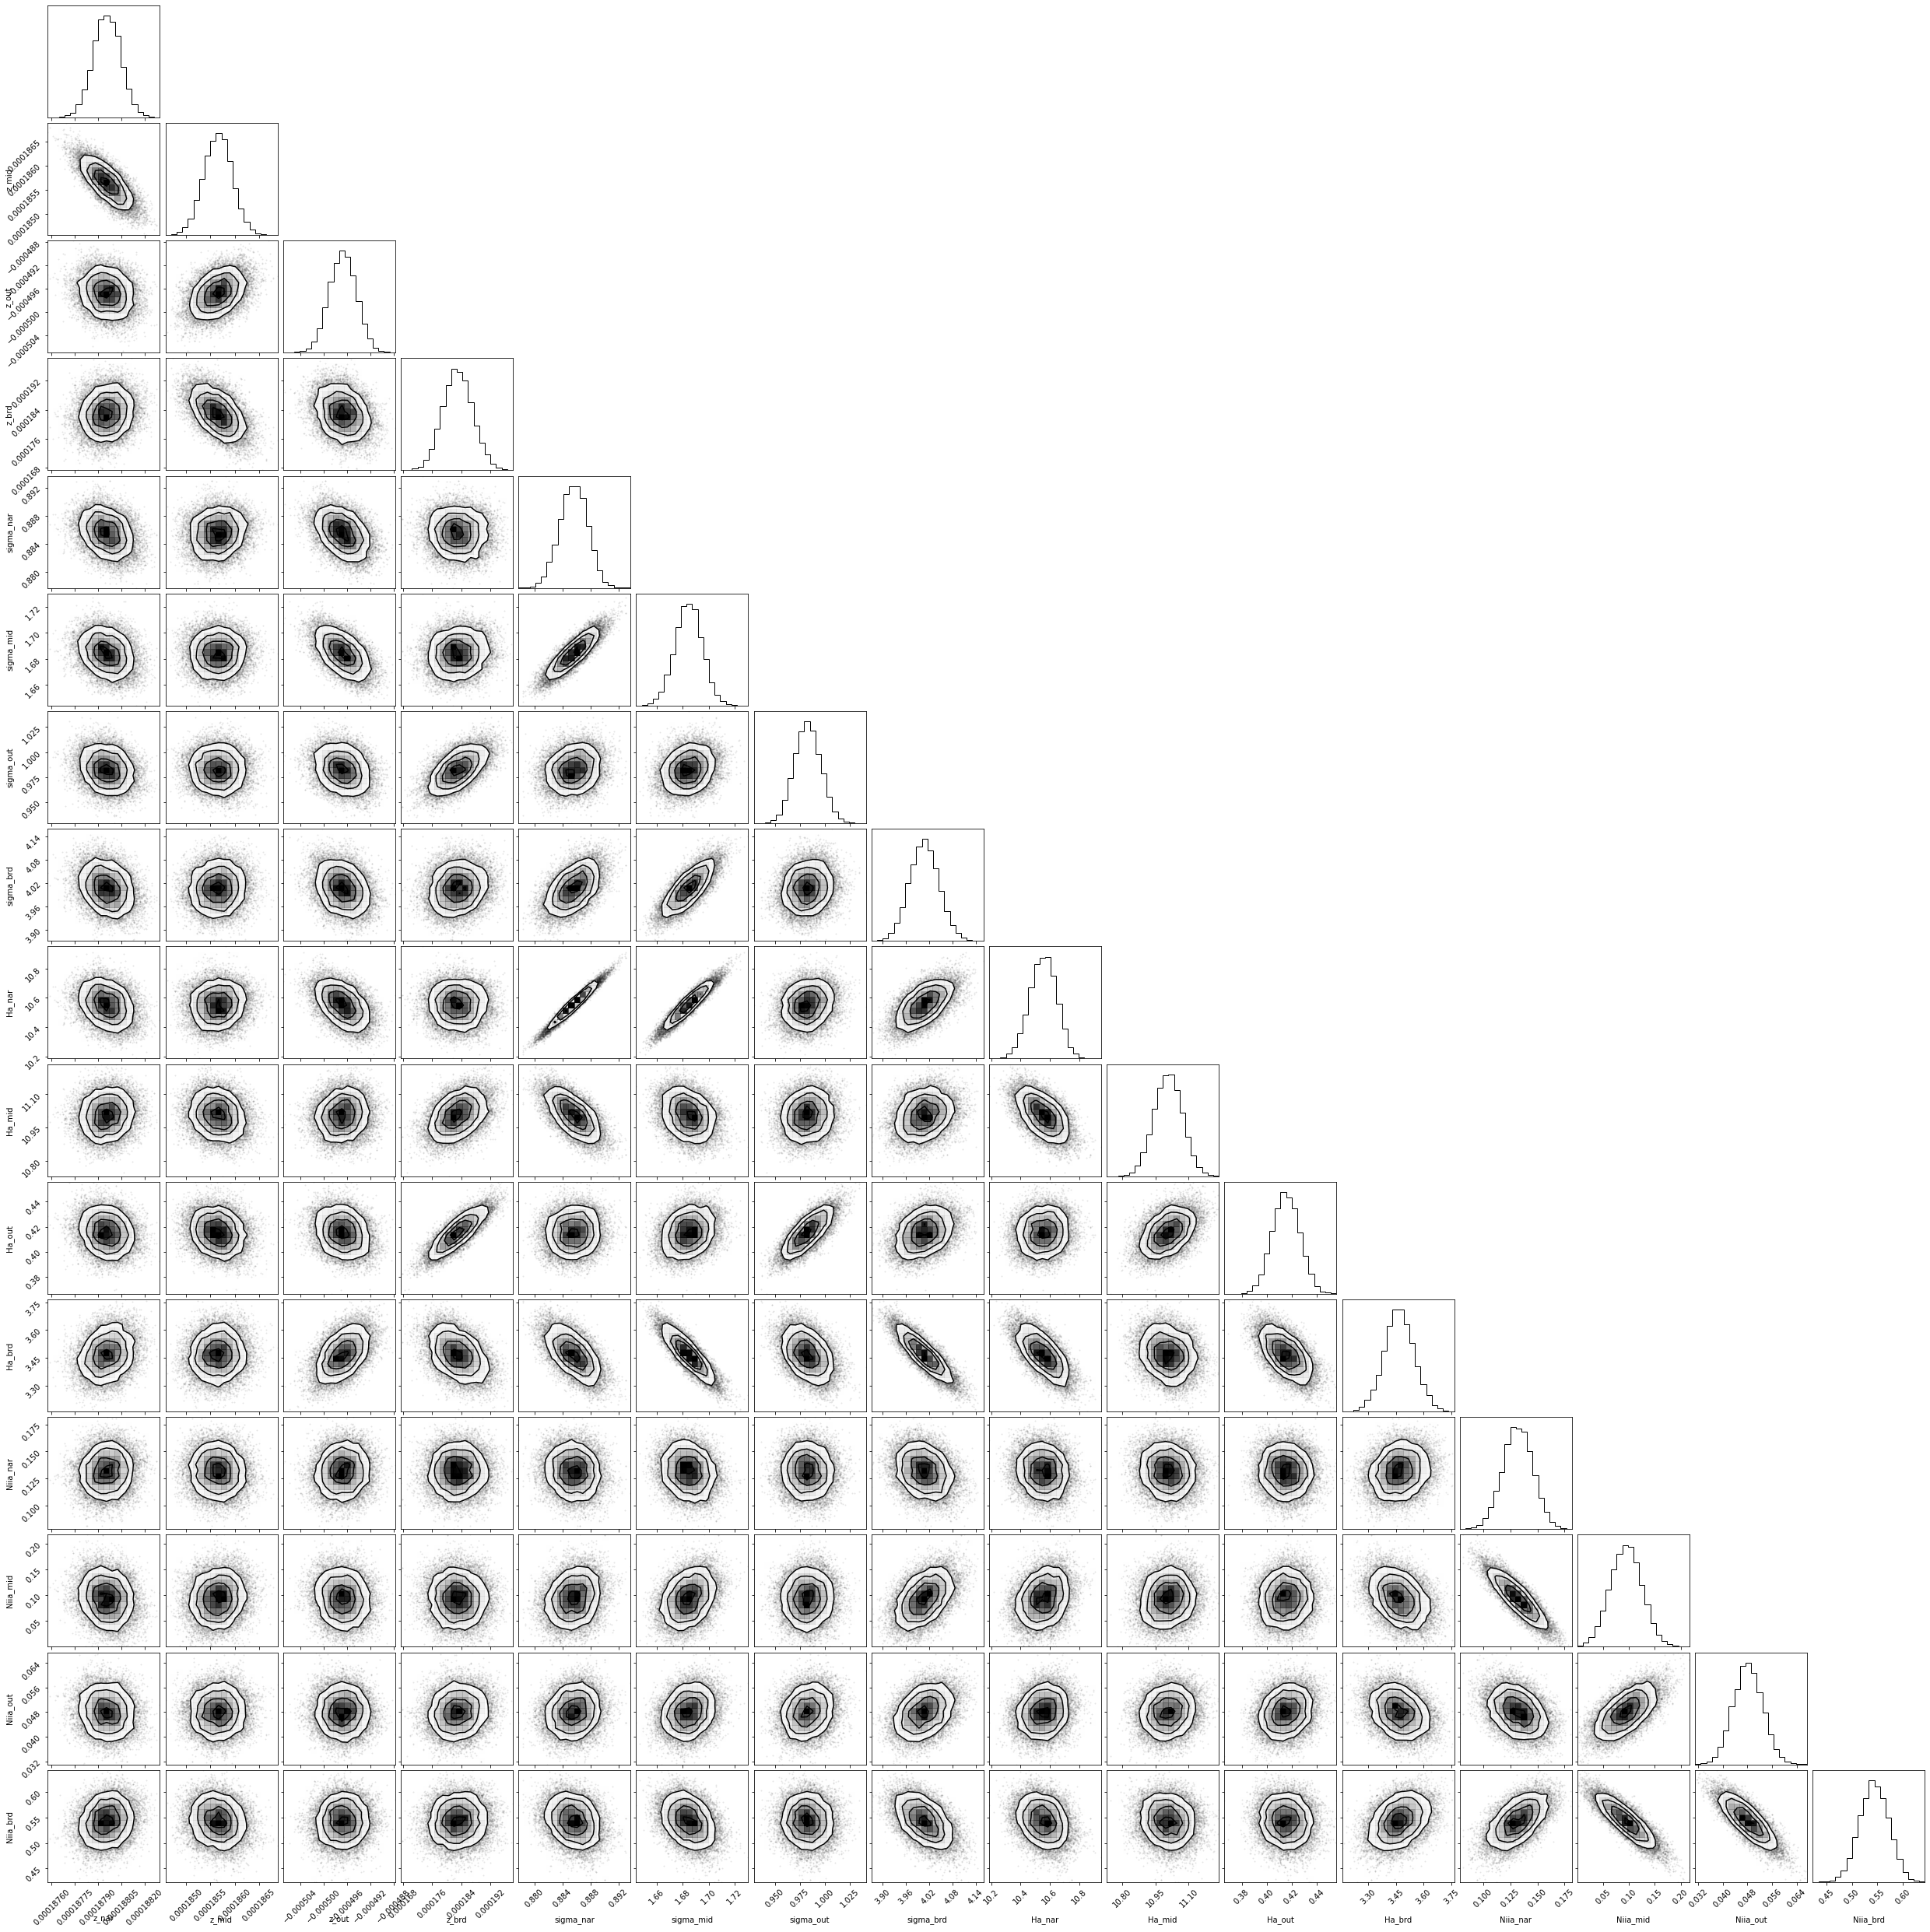

In [9]:
%matplotlib inline
corner.corner(out4_ha_nii.flatchain, labels=out4_ha_nii.var_names);

In [10]:
ha_nar = out4_ha_nii.flatchain.Ha_nar.mean()
ha_nar_err = out4_ha_nii.flatchain.Ha_nar.std()

ha_mid = out4_ha_nii.flatchain.Ha_mid.mean()
ha_mid_err = out4_ha_nii.flatchain.Ha_mid.std()

ha_out = out4_ha_nii.flatchain.Ha_out.mean()
ha_out_err = out4_ha_nii.flatchain.Ha_out.std()

ha_brd = out4_ha_nii.flatchain.Ha_brd.mean()
ha_brd_err = out4_ha_nii.flatchain.Ha_brd.std()

niia_nar = out4_ha_nii.flatchain.Niia_nar.mean()
niia_nar_err = out4_ha_nii.flatchain.Niia_nar.std()

niia_mid = out4_ha_nii.flatchain.Niia_mid.mean()
niia_mid_err = out4_ha_nii.flatchain.Niia_mid.std()

niia_out = out4_ha_nii.flatchain.Niia_out.mean()
niia_out_err = out4_ha_nii.flatchain.Niia_out.std()

niia_brd = out4_ha_nii.flatchain.Niia_brd.mean()
niia_brd_err = out4_ha_nii.flatchain.Niia_brd.std()

niib_nar = (out4_ha_nii.flatchain.Niia_nar/3).mean()
niib_nar_err = (out4_ha_nii.flatchain.Niia_nar/3).std()

niib_mid = (out4_ha_nii.flatchain.Niia_mid/3).mean()
niib_mid_err = (out4_ha_nii.flatchain.Niia_mid/3).std()

niib_out = (out4_ha_nii.flatchain.Niia_out/3).mean()
niib_out_err = (out4_ha_nii.flatchain.Niia_out/3).std()

niib_brd = (out4_ha_nii.flatchain.Niia_brd/3).mean()
niib_brd_err = (out4_ha_nii.flatchain.Niia_brd/3).std()

z_ha_nar = out4_ha_nii.flatchain.z_nar.mean()
z_ha_nar_err = out4_ha_nii.flatchain.z_nar.std()

z_ha_mid = out4_ha_nii.flatchain.z_mid.mean()
z_ha_mid_err = out4_ha_nii.flatchain.z_mid.std()

z_ha_out = out4_ha_nii.flatchain.z_out.mean()
z_ha_out_err = out4_ha_nii.flatchain.z_out.std()

z_ha_brd = out4_ha_nii.flatchain.z_brd.mean()
z_ha_brd_err = out4_ha_nii.flatchain.z_brd.std()

sigma_ha_nar = out4_ha_nii.flatchain.sigma_nar.mean()
sigma_ha_nar_err = out4_ha_nii.flatchain.sigma_nar.std()

sigma_ha_mid = out4_ha_nii.flatchain.sigma_mid.mean()
sigma_ha_mid_err = out4_ha_nii.flatchain.sigma_mid.std()

sigma_ha_out = out4_ha_nii.flatchain.sigma_out.mean()
sigma_ha_out_err = out4_ha_nii.flatchain.sigma_out.std()

sigma_ha_brd = out4_ha_nii.flatchain.sigma_brd.mean()
sigma_ha_brd_err = out4_ha_nii.flatchain.sigma_brd.std()

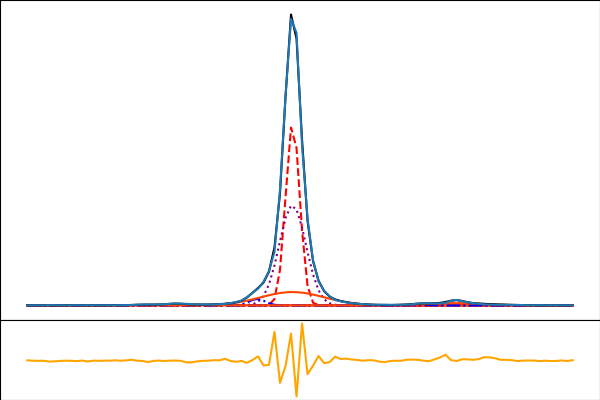

In [11]:
# Search for good initial guess
%matplotlib widget
fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))
ax.errorbar(wl_ha, flux_ha, noise_ha, markersize=2, label='data')


ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

niib_nar = gaussian(wl_ha, niib_nar, niib_wav, z=z_ha_nar, sigma=sigma_ha_nar)
niib_mid = gaussian(wl_ha, niib_mid, niib_wav, z=z_ha_mid, sigma=sigma_ha_mid)
niib_out = gaussian(wl_ha, niib_out, niib_wav, z=z_ha_out, sigma=sigma_ha_out)
niib_brd = gaussian(wl_ha, niib_brd, niib_wav, z=z_ha_brd, sigma=sigma_ha_brd)

ha_nar = gaussian(wl_ha, ha_nar, ha_wav, z=z_ha_nar, sigma=sigma_ha_nar)
ha_mid = gaussian(wl_ha, ha_mid, ha_wav, z=z_ha_mid, sigma=sigma_ha_mid)
ha_out = gaussian(wl_ha, ha_out, ha_wav, z=z_ha_out, sigma=sigma_ha_out)
ha_brd = gaussian(wl_ha, ha_brd, ha_wav, z=z_ha_brd, sigma=sigma_ha_brd)

niia_nar = gaussian(wl_ha, niia_nar, niia_wav, z=z_ha_nar, sigma=sigma_ha_nar)
niia_mid = gaussian(wl_ha, niia_mid, niia_wav, z=z_ha_mid, sigma=sigma_ha_mid)
niia_out = gaussian(wl_ha, niia_out, niia_wav, z=z_ha_out, sigma=sigma_ha_out)
niia_brd = gaussian(wl_ha, niia_brd, niia_wav, z=z_ha_brd, sigma=sigma_ha_brd)

# total
ha = ha_nar + ha_mid + ha_out + ha_brd
niib = niib_nar + niib_mid + niib_out + niib_brd
niia = niia_nar + niia_mid + niia_out + niia_brd

ax.plot(wl_ha, ha_nar, color='red', ls='--')
ax.plot(wl_ha, ha_mid, color='purple', ls=':')
ax.plot(wl_ha, ha_out, color='blue', ls='-.')
ax.plot(wl_ha, ha_brd, color='orangered')

ax.plot(wl_ha, niib_nar, color='red', ls='--')
ax.plot(wl_ha, niib_mid, color='purple', ls=':')
ax.plot(wl_ha, niib_out, color='blue', ls='-.')
ax.plot(wl_ha, niib_brd, color='orangered')

ax.plot(wl_ha, niia_nar, color='red', ls='--')
ax.plot(wl_ha, niia_mid, color='purple', ls=':')
ax.plot(wl_ha, niia_out, color='blue', ls='-.')
ax.plot(wl_ha, niia_brd, color='orangered')

ax.plot(wl_ha, niib + ha + niia, color='black')
ax1.plot(wl_ha, niib + ha + niia - flux_ha, color='orange')

## [OII]$\lambda$7319 + [OII]$\lambda$7330

In [12]:
oii7_mask = (wl > 7295) & (wl < 7355)
wl_oii7 = wl[oii7_mask]
flux_oii7 = flux[oii7_mask]
noise_oii7 = noise[oii7_mask]

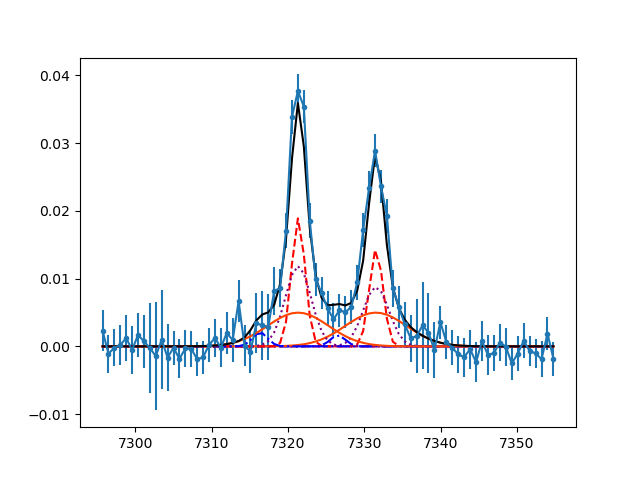

In [13]:
# Search for good initial guess
%matplotlib widget
plt.errorbar(wl_oii7, flux_oii7, noise_oii7,
             marker='o', markersize=3, label='data')

# air (NIST)
oii7b_wav = 7319.99
oii7a_wav = 7330.19

# narrow and broad

oii7a_nar = gaussian(wl_oii7, 0.032, oii7a_wav, z=z_ha_nar, sigma=sigma_ha_nar)
oii7a_mid = gaussian(wl_oii7, 0.037, oii7a_wav, z=z_ha_mid, sigma=sigma_ha_mid)
oii7a_out = gaussian(wl_oii7, 0.004, oii7a_wav, z=z_ha_out, sigma=sigma_ha_out)
oii7a_brd = gaussian(wl_oii7,  0.05, oii7a_wav, z=z_ha_brd, sigma=sigma_ha_brd)

oii7b_nar = gaussian(wl_oii7, 0.042, oii7b_wav, z=z_ha_nar, sigma=sigma_ha_nar)
oii7b_mid = gaussian(wl_oii7, 0.050, oii7b_wav, z=z_ha_mid, sigma=sigma_ha_mid)
oii7b_out = gaussian(wl_oii7, 0.005, oii7b_wav, z=z_ha_out, sigma=sigma_ha_out)
oii7b_brd = gaussian(wl_oii7,  0.05, oii7b_wav, z=z_ha_brd, sigma=sigma_ha_brd)

# total
oii7b = oii7b_nar + oii7b_mid + oii7b_out + oii7b_brd
oii7a = oii7a_nar + oii7a_mid + oii7a_out + oii7a_brd

plt.plot(wl_oii7, oii7a_nar, color='red', ls='--')
plt.plot(wl_oii7, oii7a_mid, color='purple', ls=':')
plt.plot(wl_oii7, oii7a_out, color='blue', ls='-.')
plt.plot(wl_oii7, oii7a_brd, color='orangered')

plt.plot(wl_oii7, oii7b_nar, color='red', ls='--')
plt.plot(wl_oii7, oii7b_mid, color='purple', ls=':')
plt.plot(wl_oii7, oii7b_out, color='blue', ls='-.')
plt.plot(wl_oii7, oii7b_brd, color='orangered')

plt.plot(wl_oii7, oii7b + oii7a, color='black')

In [14]:
params_oii7 = Parameters()

params_oii7.add('z_nar', value=z_ha_nar, vary=False)
params_oii7.add('z_mid', value=z_ha_mid, vary=False)
params_oii7.add('z_out', value=z_ha_out, vary=False)
params_oii7.add('z_brd', value=z_ha_brd, vary=False)

params_oii7.add('sigma_nar', value=sigma_ha_nar, vary=False)
params_oii7.add('sigma_mid', value=sigma_ha_mid, vary=False)
params_oii7.add('sigma_out', value=sigma_ha_out, vary=False)
params_oii7.add('sigma_brd', value=sigma_ha_brd, vary=False)

params_oii7.add('Oii7a_nar', value=0.032, min=0.)
params_oii7.add('Oii7a_mid', value=0.037, min=0.)
params_oii7.add('Oii7a_out', value=0.004, min=0.)
params_oii7.add('Oii7a_brd',  value=0.05, min=0.)

params_oii7.add('Oii7b_nar', value=0.042, min=0.)
params_oii7.add('Oii7b_mid', value=0.050, min=0.)
params_oii7.add('Oii7b_out', value=0.005, min=0.)
params_oii7.add('Oii7b_brd',  value=0.05, min=0.)


def residual_oii7(params_oii7, x, data, uncertainty):
    oii7b_wav = 7319.99
    oii7a_wav = 7330.19
    
    z_nar = params_oii7['z_nar']
    z_mid = params_oii7['z_mid']
    z_out = params_oii7['z_out']
    z_brd = params_oii7['z_brd']
    
    sigma_nar = params_oii7['sigma_nar']
    sigma_mid = params_oii7['sigma_mid']
    sigma_out = params_oii7['sigma_out']
    sigma_brd = params_oii7['sigma_brd']
    
    oii7a_nar = params_oii7['Oii7a_nar']
    oii7a_mid = params_oii7['Oii7a_mid']
    oii7a_out = params_oii7['Oii7a_out']
    oii7a_brd = params_oii7['Oii7a_brd']
    
    oii7b_nar = params_oii7['Oii7b_nar']
    oii7b_mid = params_oii7['Oii7b_mid']
    oii7b_out = params_oii7['Oii7b_out']
    oii7b_brd = params_oii7['Oii7b_brd']
    
    x = wl_oii7
    
    model_oii7a = gaussian(x, oii7a_nar, oii7a_wav, z_nar, sigma_nar) \
               + gaussian(x, oii7a_mid, oii7a_wav, z_mid, sigma_mid) \
               + gaussian(x, oii7a_out, oii7a_wav, z_out, sigma_out) \
               + gaussian(x, oii7a_brd, oii7a_wav, z_brd, sigma_brd) \
    
    model_oii7b = gaussian(x, oii7b_nar, oii7b_wav, z_nar, sigma_nar) \
               + gaussian(x, oii7b_mid, oii7b_wav, z_mid, sigma_mid) \
               + gaussian(x, oii7b_out, oii7b_wav, z_out, sigma_out) \
               + gaussian(x, oii7b_brd, oii7b_wav, z_brd, sigma_brd) \
    
    model = model_oii7b + model_oii7a
    return (model - flux_oii7) / noise_oii7

In [15]:
out_oii7 = minimize(residual_oii7, params_oii7, args=(1, 1, 1),
                      method='emcee', burn=1200, steps=3000, thin=10,
                      workers=12, seed=1)

100%|███████████████████████████████████████| 3000/3000 [00:33<00:00, 89.61it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 8 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [110.39237978 104.09090249 111.7208394   98.09772576  94.74980697
 102.95043028 108.54979429 102.11155098]


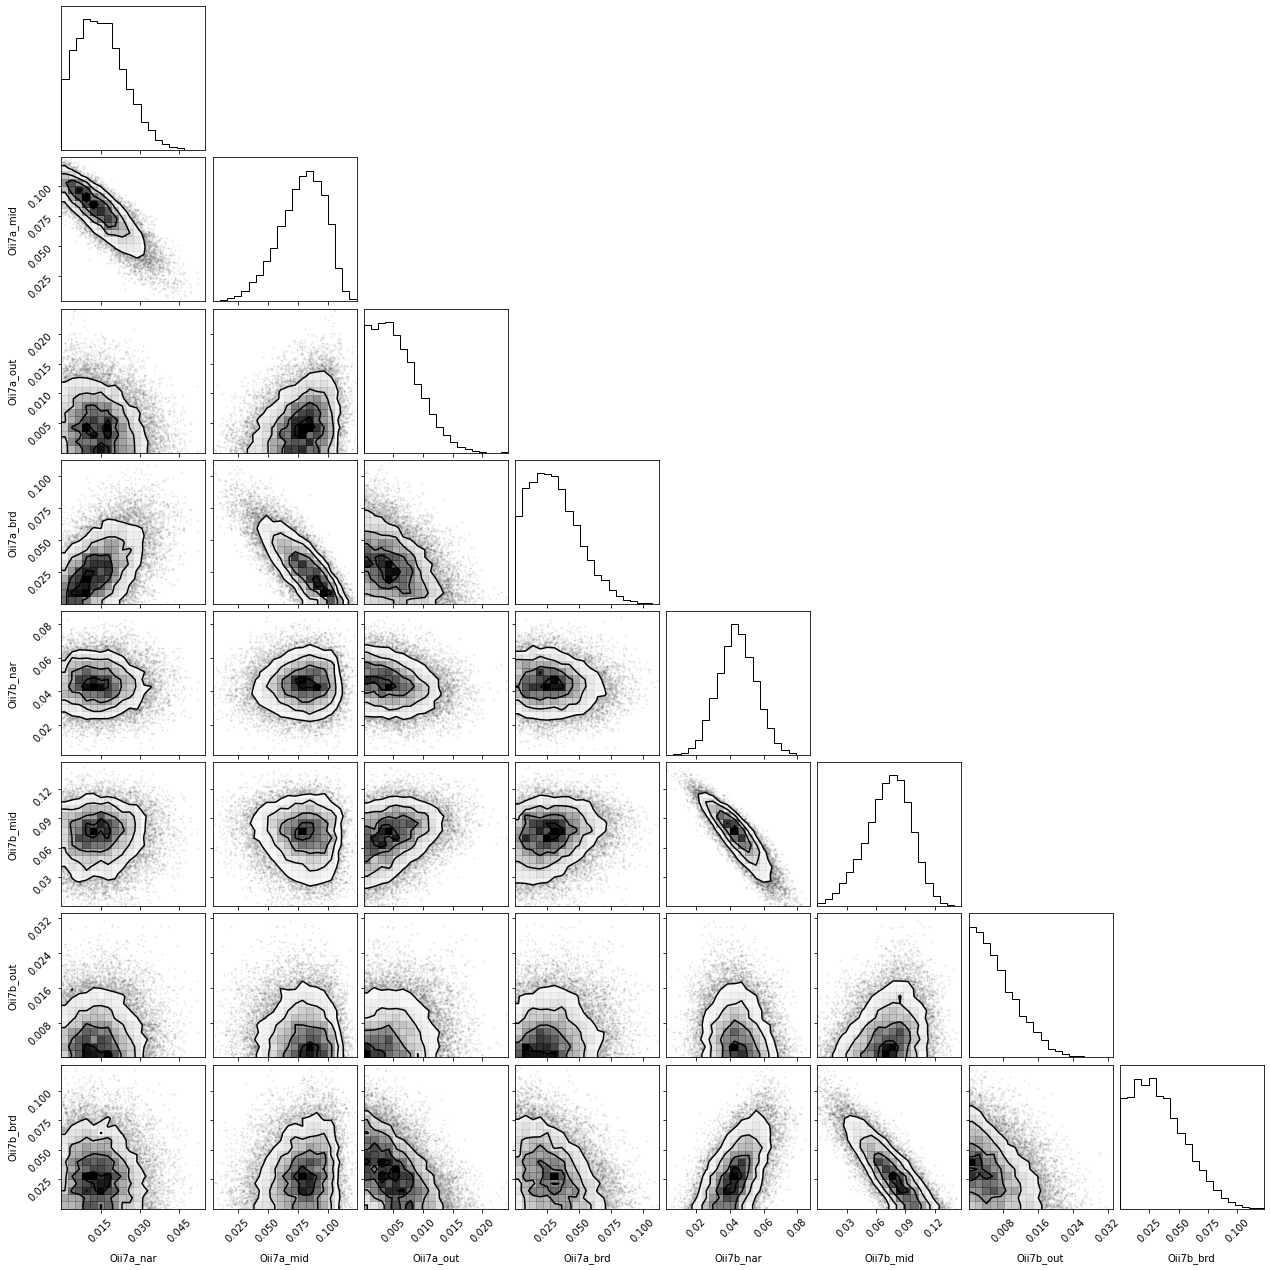

In [17]:
%matplotlib inline
corner.corner(out_oii7.flatchain, labels=out_oii7.var_names);
#plt.savefig('corner_oii73.png', bbox_inches='tight', facecolor='white')

In [29]:
oii7a_nar = out_oii7.flatchain.Oii7a_nar.mean()
oii7a_nar_err = out_oii7.flatchain.Oii7a_nar.std()

oii7a_mid = out_oii7.flatchain.Oii7a_mid.mean()
oii7a_mid_err = out_oii7.flatchain.Oii7a_mid.std()

oii7a_out = out_oii7.flatchain.Oii7a_out.mean()
oii7a_out_err = out_oii7.flatchain.Oii7a_out.std()

oii7a_brd = out_oii7.flatchain.Oii7a_brd.mean()
oii7a_brd_err = out_oii7.flatchain.Oii7a_brd.std()

oii7b_nar = (out_oii7.flatchain.Oii7b_nar).mean()
oii7b_nar_err = (out_oii7.flatchain.Oii7b_nar).std()

oii7b_mid = (out_oii7.flatchain.Oii7b_mid).mean()
oii7b_mid_err = (out_oii7.flatchain.Oii7b_mid).std()

oii7b_out = (out_oii7.flatchain.Oii7b_out).mean()
oii7b_out_err = (out_oii7.flatchain.Oii7b_out).std()

oii7b_brd = (out_oii7.flatchain.Oii7b_brd).mean()
oii7b_brd_err = (out_oii7.flatchain.Oii7b_brd).std()

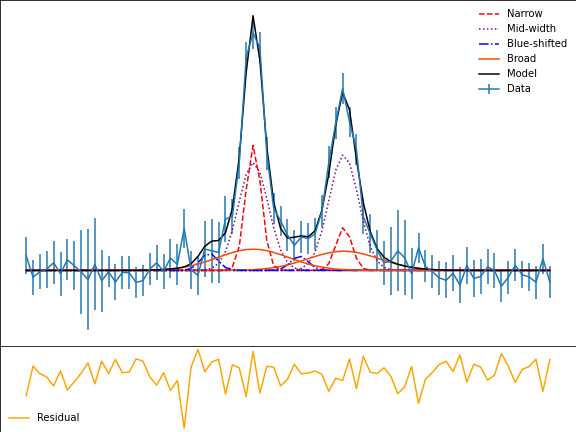

In [30]:
# Search for good initial guess
%matplotlib widget
fig = plt.figure(1)
fig.set_size_inches(8, 6)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))
ax.errorbar(wl_oii7, flux_oii7, noise_oii7, markersize=2, label='Data')

oii7a_nar = gaussian(wl_oii7, oii7a_nar, oii7a_wav, z=z_ha_nar, sigma=sigma_ha_nar)
oii7a_mid = gaussian(wl_oii7, oii7a_mid, oii7a_wav, z=z_ha_mid, sigma=sigma_ha_mid)
oii7a_out = gaussian(wl_oii7, oii7a_out, oii7a_wav, z=z_ha_out, sigma=sigma_ha_out)
oii7a_brd = gaussian(wl_oii7, oii7a_brd, oii7a_wav, z=z_ha_brd, sigma=sigma_ha_brd)

oii7b_nar = gaussian(wl_oii7, oii7b_nar, oii7b_wav, z=z_ha_nar, sigma=sigma_ha_nar)
oii7b_mid = gaussian(wl_oii7, oii7b_mid, oii7b_wav, z=z_ha_mid, sigma=sigma_ha_mid)
oii7b_out = gaussian(wl_oii7, oii7b_out, oii7b_wav, z=z_ha_out, sigma=sigma_ha_out)
oii7b_brd = gaussian(wl_oii7, oii7b_brd, oii7b_wav, z=z_ha_brd, sigma=sigma_ha_brd)

# total
oii7b = oii7b_nar + oii7b_mid + oii7b_out + oii7b_brd
oii7a = oii7a_nar + oii7a_mid + oii7a_out + oii7a_brd

ax.plot(wl_oii7, oii7a_nar, color='red', ls='--', label='Narrow')
ax.plot(wl_oii7, oii7a_mid, color='purple', ls=':', label='Mid-width')
ax.plot(wl_oii7, oii7a_out, color='blue', ls='-.', label='Blue-shifted')
ax.plot(wl_oii7, oii7a_brd, color='orangered', label='Broad')

ax.plot(wl_oii7, oii7b_nar, color='red', ls='--')
ax.plot(wl_oii7, oii7b_mid, color='purple', ls=':')
ax.plot(wl_oii7, oii7b_out, color='blue', ls='-.')
ax.plot(wl_oii7, oii7b_brd, color='orangered')

ax.plot(wl_oii7, oii7b + oii7a, color='black', label='Model')
ax1.plot(wl_oii7, oii7b + oii7a - flux_oii7, color='orange', label='Residual')
ax.legend(frameon=False)
ax1.legend(frameon=False)
#plt.savefig('4compfit_oii73.png', bbox_inches='tight', facecolor='white')

## [SII]$\lambda$6716 + [SII]$\lambda$6731

In [31]:
sii_mask = (wl > 6695) & (wl < 6755)
wl_sii = wl[sii_mask]
flux_sii = flux[sii_mask]
noise_sii = noise[sii_mask]

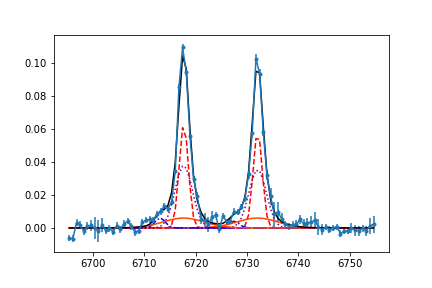

In [32]:
# Search for good initial guess
%matplotlib widget
plt.errorbar(wl_sii, flux_sii, noise_sii,
             marker='o', markersize=3, label='data')

# air (NIST)
siib_wav = 6716.44
siia_wav = 6730.82

# narrow and broad

siia_nar = gaussian(wl_sii, 0.13, siia_wav, z=z_ha_nar, sigma=sigma_ha_nar)
siia_mid = gaussian(wl_sii, 0.15, siia_wav, z=z_ha_mid, sigma=sigma_ha_mid)
siia_out = gaussian(wl_sii, 0.01, siia_wav, z=z_ha_out, sigma=sigma_ha_out)
siia_brd = gaussian(wl_sii, 0.06, siia_wav, z=z_ha_brd, sigma=sigma_ha_brd)

siib_nar = gaussian(wl_sii, 0.14, siib_wav, z=z_ha_nar, sigma=sigma_ha_nar)
siib_mid = gaussian(wl_sii, 0.16, siib_wav, z=z_ha_mid, sigma=sigma_ha_mid)
siib_out = gaussian(wl_sii, 0.015, siib_wav, z=z_ha_out, sigma=sigma_ha_out)
siib_brd = gaussian(wl_sii, 0.06, siib_wav, z=z_ha_brd, sigma=sigma_ha_brd)

# total
siib = siib_nar + siib_mid + siib_out + siib_brd
siia = siia_nar + siia_mid + siia_out + siia_brd

plt.plot(wl_sii, siia_nar, color='red', ls='--')
plt.plot(wl_sii, siia_mid, color='purple', ls=':')
plt.plot(wl_sii, siia_out, color='blue', ls='-.')
plt.plot(wl_sii, siia_brd, color='orangered')

plt.plot(wl_sii, siib_nar, color='red', ls='--')
plt.plot(wl_sii, siib_mid, color='purple', ls=':')
plt.plot(wl_sii, siib_out, color='blue', ls='-.')
plt.plot(wl_sii, siib_brd, color='orangered')

plt.plot(wl_sii, siib + siia, color='black')

In [33]:
params_sii = Parameters()

params_sii.add('z_nar', value=z_ha_nar, vary=False)
params_sii.add('z_mid', value=z_ha_mid, vary=False)
params_sii.add('z_out', value=z_ha_out, vary=False)
params_sii.add('z_brd', value=z_ha_brd, vary=False)

params_sii.add('sigma_nar', value=sigma_ha_nar, vary=False)
params_sii.add('sigma_mid', value=sigma_ha_mid, vary=False)
params_sii.add('sigma_out', value=sigma_ha_out, vary=False)
params_sii.add('sigma_brd', value=sigma_ha_brd, vary=False)

params_sii.add('Siia_nar', value=0.032, min=0.)
params_sii.add('Siia_mid', value=0.037, min=0.)
params_sii.add('Siia_out', value=0.004, min=0.)
params_sii.add('Siia_brd',  value=0.05, min=0.)

params_sii.add('Siib_nar', value=0.042, min=0.)
params_sii.add('Siib_mid', value=0.050, min=0.)
params_sii.add('Siib_out', value=0.005, min=0.)
params_sii.add('Siib_brd',  value=0.05, min=0.)


def residual_sii(params_sii, x, data, uncertainty):
    siib_wav = 6716.44
    siia_wav = 6730.82
    
    z_nar = params_sii['z_nar']
    z_mid = params_sii['z_mid']
    z_out = params_sii['z_out']
    z_brd = params_sii['z_brd']
    
    sigma_nar = params_sii['sigma_nar']
    sigma_mid = params_sii['sigma_mid']
    sigma_out = params_sii['sigma_out']
    sigma_brd = params_sii['sigma_brd']
    
    siia_nar = params_sii['Siia_nar']
    siia_mid = params_sii['Siia_mid']
    siia_out = params_sii['Siia_out']
    siia_brd = params_sii['Siia_brd']
    
    siib_nar = params_sii['Siib_nar']
    siib_mid = params_sii['Siib_mid']
    siib_out = params_sii['Siib_out']
    siib_brd = params_sii['Siib_brd']
    
    x = wl_sii
    
    model_siia = gaussian(x, siia_nar, siia_wav, z_nar, sigma_nar) \
               + gaussian(x, siia_mid, siia_wav, z_mid, sigma_mid) \
               + gaussian(x, siia_out, siia_wav, z_out, sigma_out) \
               + gaussian(x, siia_brd, siia_wav, z_brd, sigma_brd) \
    
    model_siib = gaussian(x, siib_nar, siib_wav, z_nar, sigma_nar) \
               + gaussian(x, siib_mid, siib_wav, z_mid, sigma_mid) \
               + gaussian(x, siib_out, siib_wav, z_out, sigma_out) \
               + gaussian(x, siib_brd, siib_wav, z_brd, sigma_brd) \
    
    model = model_siib + model_siia
    return (model - flux_sii) / noise_sii

In [34]:
out_sii = minimize(residual_sii, params_sii, args=(1, 1, 1),
                      method='emcee', burn=1200, steps=3000, thin=10,
                      workers=12, seed=1)

100%|███████████████████████████████████████| 3000/3000 [00:42<00:00, 69.94it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [133.00236678  56.15643175  85.64171725  71.19906404 105.35983181
  70.81649874  66.46300574  65.98652257]


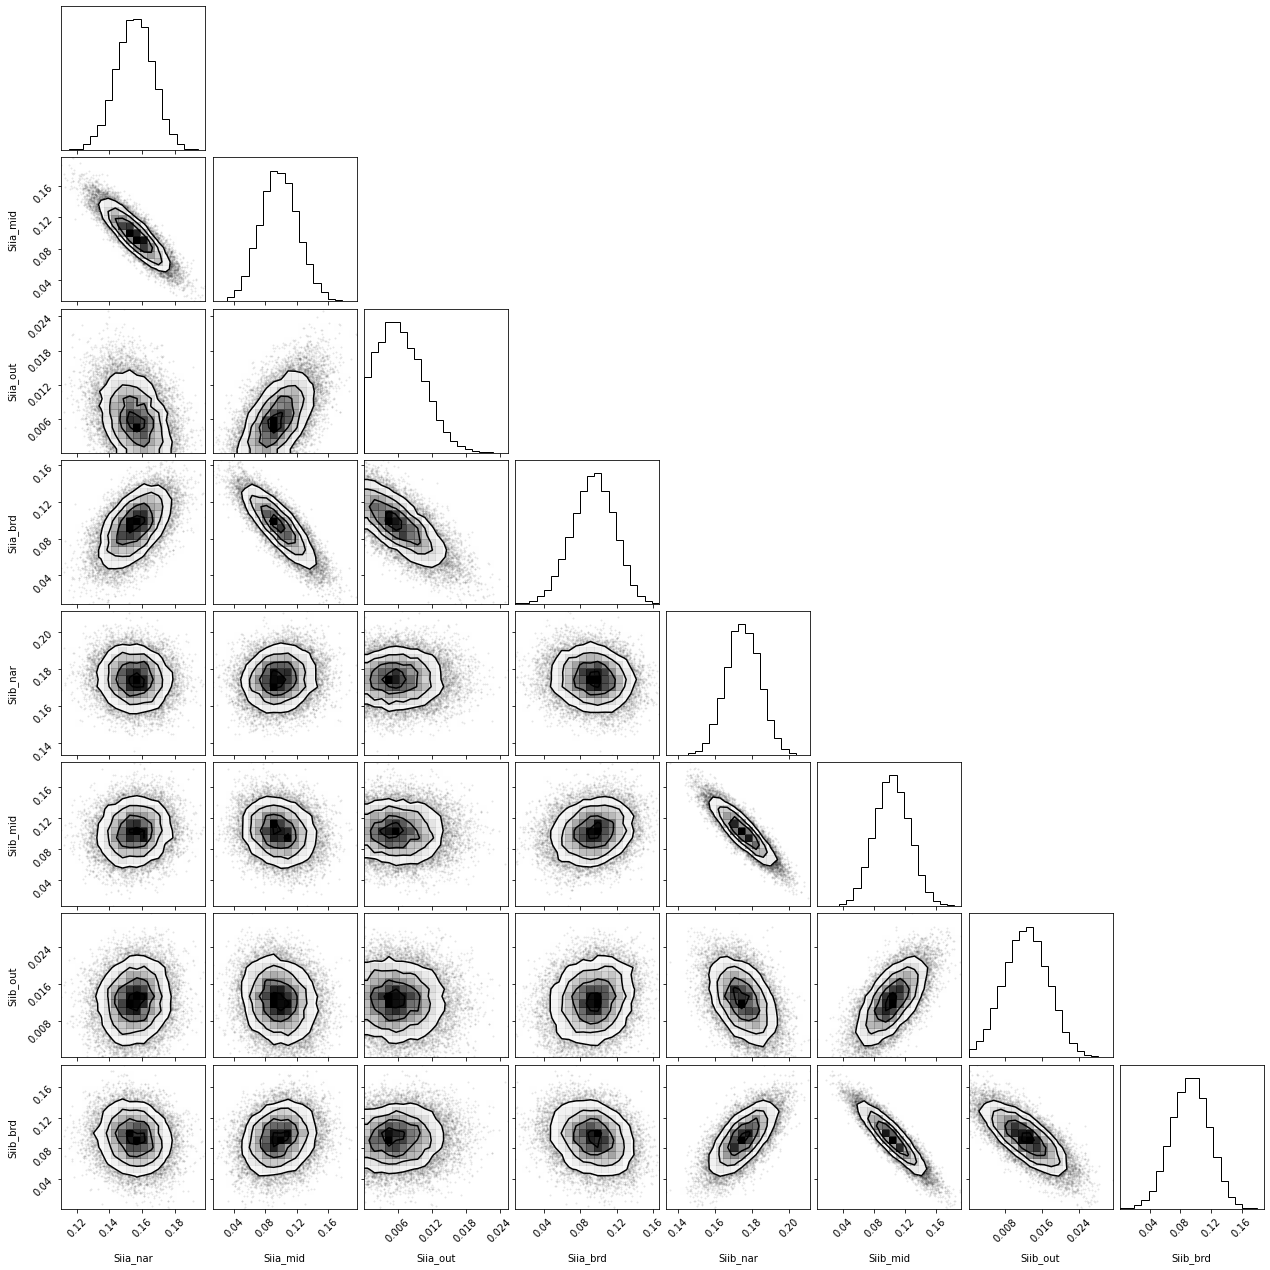

In [35]:
%matplotlib inline
corner.corner(out_sii.flatchain, labels=out_sii.var_names);
#plt.savefig('corner_sii67.png', bbox_inches='tight', facecolor='white')

In [40]:
siia_nar = out_sii.flatchain.Siia_nar.mean()
siia_nar_err = out_sii.flatchain.Siia_nar.std()

siia_mid = out_sii.flatchain.Siia_mid.mean()
siia_mid_err = out_sii.flatchain.Siia_mid.std()

siia_out = out_sii.flatchain.Siia_out.mean()
siia_out_err = out_sii.flatchain.Siia_out.std()

siia_brd = out_sii.flatchain.Siia_brd.mean()
siia_brd_err = out_sii.flatchain.Siia_brd.std()

siib_nar = (out_sii.flatchain.Siib_nar).mean()
siib_nar_err = (out_sii.flatchain.Siib_nar).std()

siib_mid = (out_sii.flatchain.Siib_mid).mean()
siib_mid_err = (out_sii.flatchain.Siib_mid).std()

siib_out = (out_sii.flatchain.Siib_out).mean()
siib_out_err = (out_sii.flatchain.Siib_out).std()

siib_brd = (out_sii.flatchain.Siib_brd).mean()
siib_brd_err = (out_sii.flatchain.Siib_brd).std()

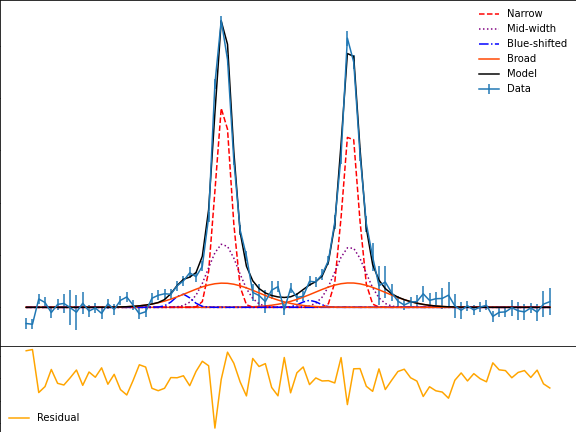

In [41]:
# Search for good initial guess
%matplotlib widget
fig = plt.figure(1)
fig.set_size_inches(8, 6)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))
ax.errorbar(wl_sii, flux_sii, noise_sii, markersize=2, label='Data')

siia_nar = gaussian(wl_sii, siia_nar, siia_wav, z=z_ha_nar, sigma=sigma_ha_nar)
siia_mid = gaussian(wl_sii, siia_mid, siia_wav, z=z_ha_mid, sigma=sigma_ha_mid)
siia_out = gaussian(wl_sii, siia_out, siia_wav, z=z_ha_out, sigma=sigma_ha_out)
siia_brd = gaussian(wl_sii, siia_brd, siia_wav, z=z_ha_brd, sigma=sigma_ha_brd)

siib_nar = gaussian(wl_sii, siib_nar, siib_wav, z=z_ha_nar, sigma=sigma_ha_nar)
siib_mid = gaussian(wl_sii, siib_mid, siib_wav, z=z_ha_mid, sigma=sigma_ha_mid)
siib_out = gaussian(wl_sii, siib_out, siib_wav, z=z_ha_out, sigma=sigma_ha_out)
siib_brd = gaussian(wl_sii, siib_brd, siib_wav, z=z_ha_brd, sigma=sigma_ha_brd)

# total
siib = siib_nar + siib_mid + siib_out + siib_brd
siia = siia_nar + siia_mid + siia_out + siia_brd

ax.plot(wl_sii, siia_nar, color='red', ls='--', label='Narrow')
ax.plot(wl_sii, siia_mid, color='purple', ls=':', label='Mid-width')
ax.plot(wl_sii, siia_out, color='blue', ls='-.', label='Blue-shifted')
ax.plot(wl_sii, siia_brd, color='orangered', label='Broad')

ax.plot(wl_sii, siib_nar, color='red', ls='--')
ax.plot(wl_sii, siib_mid, color='purple', ls=':')
ax.plot(wl_sii, siib_out, color='blue', ls='-.')
ax.plot(wl_sii, siib_brd, color='orangered')

ax.plot(wl_sii, siib + siia, color='black', label='Model')
ax1.plot(wl_sii, siib + siia - flux_sii, color='orange', label='Residual')
ax.legend(frameon=False)
ax1.legend(frameon=False)
#plt.savefig('4compfit_sii67.png', bbox_inches='tight', facecolor='white')

## H$\beta$

In [42]:
hb_mask = (wl > 4845) & (wl < 4880)
wl_hb = wl[hb_mask]
flux_hb = flux[hb_mask]
noise_hb = noise[hb_mask]

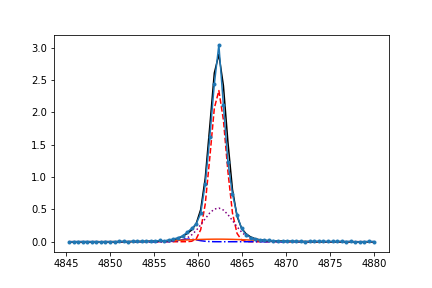

In [43]:
# Search for good initial guess
%matplotlib widget
plt.errorbar(wl_hb, flux_hb, noise_hb,
             marker='o', markersize=3, label='data')

# air
hb_wav = 4861.363

# narrow and broad

hb_nar = gaussian(wl_hb, 5.2, hb_wav, z=z_ha_nar, sigma=sigma_ha_nar)
hb_mid = gaussian(wl_hb, 2.2, hb_wav, z=z_ha_mid, sigma=sigma_ha_mid)
hb_out = gaussian(wl_hb, 0.1, hb_wav, z=z_ha_out, sigma=sigma_ha_out)
hb_brd = gaussian(wl_hb, 0.4, hb_wav, z=z_ha_brd, sigma=sigma_ha_brd)

# total
hb = hb_nar + hb_mid + hb_out + hb_brd

plt.plot(wl_hb, hb_nar, color='red', ls='--')
plt.plot(wl_hb, hb_mid, color='purple', ls=':')
plt.plot(wl_hb, hb_out, color='blue', ls='-.')
plt.plot(wl_hb, hb_brd, color='orangered')

plt.plot(wl_hb, hb, color='black')

In [44]:
params_hb = Parameters()

params_hb.add('z_nar', value=z_ha_nar, vary=False)
params_hb.add('z_mid', value=z_ha_mid, vary=False)
params_hb.add('z_out', value=z_ha_out, vary=False)
params_hb.add('z_brd', value=z_ha_brd, vary=False)

params_hb.add('sigma_nar', value=sigma_ha_nar, vary=False)
params_hb.add('sigma_mid', value=sigma_ha_mid, vary=False)
params_hb.add('sigma_out', value=sigma_ha_out, vary=False)
params_hb.add('sigma_brd', value=sigma_ha_brd, vary=False)

params_hb.add('Hb_nar', value=5.2, min=0.)
params_hb.add('Hb_mid', value=2.2, min=0.)
params_hb.add('Hb_out', value=0.1, min=0.)
params_hb.add('Hb_brd', value=0.4, min=0.)


def residual_hb(params_hb, x, data, uncertainty):
    hb_wav = 4861.363
    
    z_nar = params_hb['z_nar']
    z_mid = params_hb['z_mid']
    z_out = params_hb['z_out']
    z_brd = params_hb['z_brd']
    
    sigma_nar = params_hb['sigma_nar']
    sigma_mid = params_hb['sigma_mid']
    sigma_out = params_hb['sigma_out']
    sigma_brd = params_hb['sigma_brd']
    
    hb_nar = params_hb['Hb_nar']
    hb_mid = params_hb['Hb_mid']
    hb_out = params_hb['Hb_out']
    hb_brd = params_hb['Hb_brd']
    
    x = wl_hb
    
    model_hb = gaussian(x, hb_nar, hb_wav, z_nar, sigma_nar) \
               + gaussian(x, hb_mid, hb_wav, z_mid, sigma_mid) \
               + gaussian(x, hb_out, hb_wav, z_out, sigma_out) \
               + gaussian(x, hb_brd, hb_wav, z_brd, sigma_brd) \
    
    return (model_hb - flux_hb) / noise_hb

In [45]:
out_hb = minimize(residual_hb, params_hb, args=(1, 1, 1),
                      method='emcee', burn=1200, steps=3000, thin=10,
                      workers=12, seed=1)

100%|███████████████████████████████████████| 3000/3000 [00:30<00:00, 99.47it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 3 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [ 82.27068622  71.7804619  117.67256837  50.6805715 ]


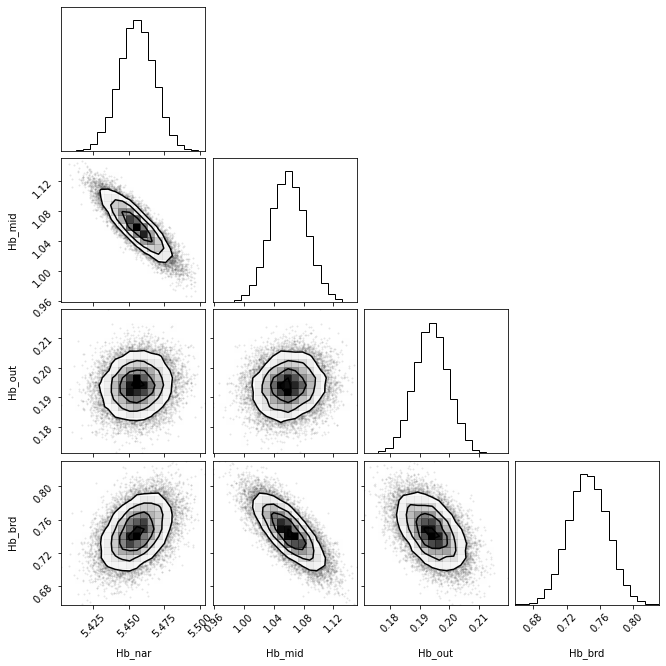

In [46]:
%matplotlib inline
corner.corner(out_hb.flatchain, labels=out_hb.var_names);
#plt.savefig('corner_hb.png', bbox_inches='tight', facecolor='white')

In [50]:
hb_nar = out_hb.flatchain.Hb_nar.mean()
hb_nar_err = out_hb.flatchain.Hb_nar.std()

hb_mid = out_hb.flatchain.Hb_mid.mean()
hb_mid_err = out_hb.flatchain.Hb_mid.std()

hb_out = out_hb.flatchain.Hb_out.mean()
hb_out_err = out_hb.flatchain.Hb_out.std()

hb_brd = out_hb.flatchain.Hb_brd.mean()
hb_brd_err = out_hb.flatchain.Hb_brd.std()

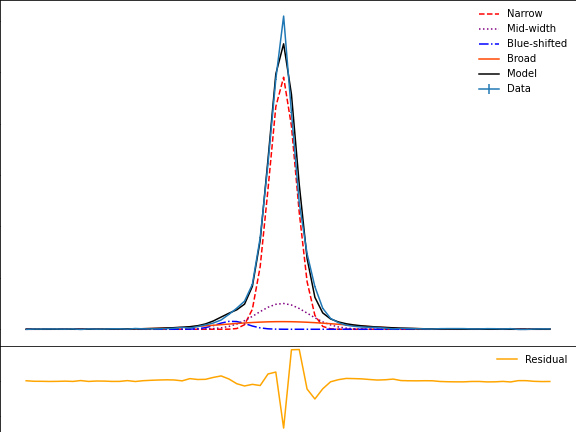

In [51]:
# Search for good initial guess
%matplotlib widget
fig = plt.figure(1)
fig.set_size_inches(8, 6)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))
ax.errorbar(wl_hb, flux_hb, noise_hb, markersize=2, label='Data')

hb_wav = 4861.363

hb_nar = gaussian(wl_hb, hb_nar, hb_wav, z=z_ha_nar, sigma=sigma_ha_nar)
hb_mid = gaussian(wl_hb, hb_mid, hb_wav, z=z_ha_mid, sigma=sigma_ha_mid)
hb_out = gaussian(wl_hb, hb_out, hb_wav, z=z_ha_out, sigma=sigma_ha_out)
hb_brd = gaussian(wl_hb, hb_brd, hb_wav, z=z_ha_brd, sigma=sigma_ha_brd)


# total
hb = hb_nar + hb_mid + hb_out + hb_brd

ax.plot(wl_hb, hb_nar, color='red', ls='--', label='Narrow')
ax.plot(wl_hb, hb_mid, color='purple', ls=':', label='Mid-width')
ax.plot(wl_hb, hb_out, color='blue', ls='-.', label='Blue-shifted')
ax.plot(wl_hb, hb_brd, color='orangered', label='Broad')

ax.plot(wl_hb, hb, color='black', label='Model')
ax1.plot(wl_hb, hb - flux_hb, color='orange', label='Residual')
ax.legend(frameon=False)
ax1.legend(frameon=False)
#plt.savefig('4compfit_hb.png', bbox_inches='tight', facecolor='white')

## [OII]$\lambda$3726 + [OII]$\lambda$3729

In [52]:
oii3_mask = (wl > 3715) & (wl < 3745)
wl_oii3 = wl[oii3_mask]
flux_oii3 = flux[oii3_mask]
noise_oii3 = noise[oii3_mask]

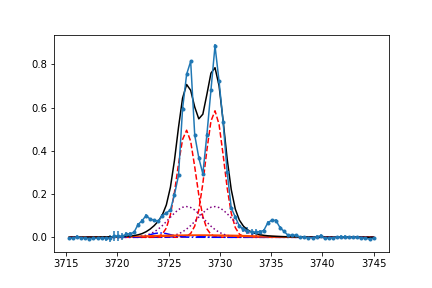

In [54]:
# Search for good initial guess
%matplotlib widget
plt.errorbar(wl_oii3, flux_oii3, noise_oii3,
             marker='o', markersize=3, label='data')

# air (NIST)
oii3b_wav = 3726.04
oii3a_wav = 3728.80

# narrow and broad

oii3a_nar = gaussian(wl_oii3,  1.3, oii3a_wav, z=z_ha_nar, sigma=sigma_ha_nar)
oii3a_mid = gaussian(wl_oii3,  0.6, oii3a_wav, z=z_ha_mid, sigma=sigma_ha_mid)
oii3a_out = gaussian(wl_oii3, 0.02, oii3a_wav, z=z_ha_out, sigma=sigma_ha_out)
oii3a_brd = gaussian(wl_oii3,  0.1, oii3a_wav, z=z_ha_brd, sigma=sigma_ha_brd)

oii3b_nar = gaussian(wl_oii3,  1.1, oii3b_wav, z=z_ha_nar, sigma=sigma_ha_nar)
oii3b_mid = gaussian(wl_oii3,  0.6, oii3b_wav, z=z_ha_mid, sigma=sigma_ha_mid)
oii3b_out = gaussian(wl_oii3, 0.05, oii3b_wav, z=z_ha_out, sigma=sigma_ha_out)
oii3b_brd = gaussian(wl_oii3,  0.1, oii3b_wav, z=z_ha_brd, sigma=sigma_ha_brd)

# total
oii3b = oii3b_nar + oii3b_mid + oii3b_out + oii3b_brd
oii3a = oii3a_nar + oii3a_mid + oii3a_out + oii3a_brd

plt.plot(wl_oii3, oii3a_nar, color='red', ls='--')
plt.plot(wl_oii3, oii3a_mid, color='purple', ls=':')
plt.plot(wl_oii3, oii3a_out, color='blue', ls='-.')
plt.plot(wl_oii3, oii3a_brd, color='orangered')

plt.plot(wl_oii3, oii3b_nar, color='red', ls='--')
plt.plot(wl_oii3, oii3b_mid, color='purple', ls=':')
plt.plot(wl_oii3, oii3b_out, color='blue', ls='-.')
plt.plot(wl_oii3, oii3b_brd, color='orangered')

plt.plot(wl_oii3, oii3b + oii3a, color='black')

In [55]:
params_oii3 = Parameters()

params_oii3.add('z_nar', value=z_ha_nar, vary=False)
params_oii3.add('z_mid', value=z_ha_mid, vary=False)
params_oii3.add('z_out', value=z_ha_out, vary=False)
params_oii3.add('z_brd', value=z_ha_brd, vary=False)

params_oii3.add('sigma_nar', value=sigma_ha_nar, vary=False)
params_oii3.add('sigma_mid', value=sigma_ha_mid, vary=False)
params_oii3.add('sigma_out', value=sigma_ha_out, vary=False)
params_oii3.add('sigma_brd', value=sigma_ha_brd, vary=False)

params_oii3.add('Oii3a_nar', value=1.3, min=0.)
params_oii3.add('Oii3a_mid', value=0.8, min=0.)
params_oii3.add('Oii3a_out', value=0.02, min=0.)
params_oii3.add('Oii3a_brd', value=0.1, min=0.)

params_oii3.add('Oii3b_to_oii3a', value=0.6, min=0.)

# params_oii3.add('Oii3b_nar', value=1.1, min=0.)
# params_oii3.add('Oii3b_mid', value=0.08, min=0.)
# params_oii3.add('Oii3b_out', value=0.05, min=0.)
# params_oii3.add('Oii3b_brd', value=0.5, min=0.)


def residual_oii3(params_oii3, x, data, uncertainty):
    oii3b_wav = 3726.04
    oii3a_wav = 3728.80
    
    z_nar = params_oii3['z_nar']
    z_mid = params_oii3['z_mid']
    z_out = params_oii3['z_out']
    z_brd = params_oii3['z_brd']
    
    sigma_nar = params_oii3['sigma_nar']
    sigma_mid = params_oii3['sigma_mid']
    sigma_out = params_oii3['sigma_out']
    sigma_brd = params_oii3['sigma_brd']
    
    oii3a_nar = params_oii3['Oii3a_nar']
    oii3a_mid = params_oii3['Oii3a_mid']
    oii3a_out = params_oii3['Oii3a_out']
    oii3a_brd = params_oii3['Oii3a_brd']
    
    oii3b_nar = params_oii3['Oii3a_nar']*params_oii3['Oii3b_to_oii3a']
    oii3b_mid = params_oii3['Oii3a_mid']*params_oii3['Oii3b_to_oii3a']
    oii3b_out = params_oii3['Oii3a_out']*params_oii3['Oii3b_to_oii3a']
    oii3b_brd = params_oii3['Oii3a_brd']*params_oii3['Oii3b_to_oii3a']
                
    #oii3b_nar = params_oii3['Oii3b_nar']
    #oii3b_mid = params_oii3['Oii3b_mid']
    #oii3b_out = params_oii3['Oii3b_out']
    #oii3b_brd = params_oii3['Oii3b_brd']
    
    x = wl_oii3
    
    model_oii3a = gaussian(x, oii3a_nar, oii3a_wav, z_nar, sigma_nar) \
               + gaussian(x, oii3a_mid, oii3a_wav, z_mid, sigma_mid) \
               + gaussian(x, oii3a_out, oii3a_wav, z_out, sigma_out) \
               + gaussian(x, oii3a_brd, oii3a_wav, z_brd, sigma_brd) \
    
    model_oii3b = gaussian(x, oii3b_nar, oii3b_wav, z_nar, sigma_nar) \
               + gaussian(x, oii3b_mid, oii3b_wav, z_mid, sigma_mid) \
               + gaussian(x, oii3b_out, oii3b_wav, z_out, sigma_out) \
               + gaussian(x, oii3b_brd, oii3b_wav, z_brd, sigma_brd) \
    
    model = model_oii3b + model_oii3a
    return (model - flux_oii3) / noise_oii3

In [56]:
out_oii3 = minimize(residual_oii3, params_oii3, args=(1, 1, 1),
                      method='emcee', burn=1200, steps=3000, thin=10,
                      workers=12, seed=1)

100%|███████████████████████████████████████| 3000/3000 [00:45<00:00, 65.63it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [105.31627394  78.23689489 158.7167545   65.04645854  25.34390404]


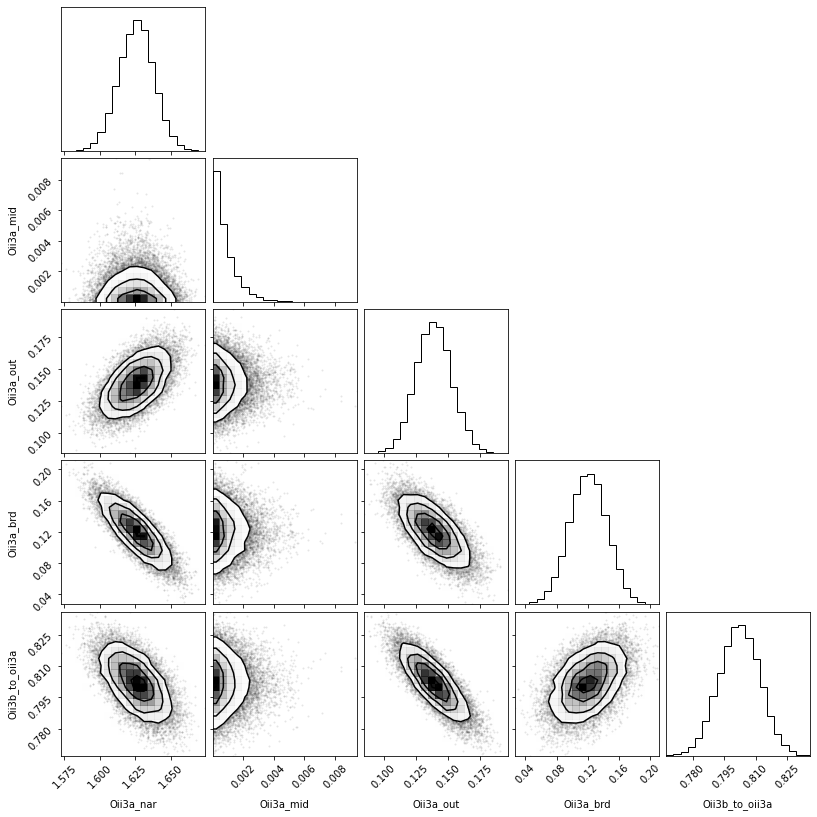

In [57]:
%matplotlib inline
corner.corner(out_oii3.flatchain, labels=out_oii3.var_names);
#plt.savefig('corner_oii37.png', bbox_inches='tight', facecolor='white')

In [58]:
oii3a_nar = out_oii3.flatchain.Oii3a_nar.mean()
oii3a_nar_err = out_oii3.flatchain.Oii3a_nar.std()

oii3a_mid = out_oii3.flatchain.Oii3a_mid.mean()
oii3a_mid_err = out_oii3.flatchain.Oii3a_mid.std()

oii3a_out = out_oii3.flatchain.Oii3a_out.mean()
oii3a_out_err = out_oii3.flatchain.Oii3a_out.std()

oii3a_brd = out_oii3.flatchain.Oii3a_brd.mean()
oii3a_brd_err = out_oii3.flatchain.Oii3a_brd.std()

oii3b_nar = (out_oii3.flatchain.Oii3a_nar*out_oii3.flatchain.Oii3b_to_oii3a).mean()
oii3b_nar_err = (out_oii3.flatchain.Oii3a_nar*out_oii3.flatchain.Oii3b_to_oii3a).std()

oii3b_mid = (out_oii3.flatchain.Oii3a_mid*out_oii3.flatchain.Oii3b_to_oii3a).mean()
oii3b_mid_err = (out_oii3.flatchain.Oii3a_mid*out_oii3.flatchain.Oii3b_to_oii3a).std()

oii3b_out = (out_oii3.flatchain.Oii3a_out*out_oii3.flatchain.Oii3b_to_oii3a).mean()
oii3b_out_err = (out_oii3.flatchain.Oii3a_out*out_oii3.flatchain.Oii3b_to_oii3a).std()

oii3b_brd = (out_oii3.flatchain.Oii3a_brd*out_oii3.flatchain.Oii3b_to_oii3a).mean()
oii3b_brd_err = (out_oii3.flatchain.Oii3a_brd*out_oii3.flatchain.Oii3b_to_oii3a).std()

#oii3b_nar = (out_oii3.flatchain.Oii3b_nar).mean()
#oii3b_nar_err = (out_oii3.flatchain.Oii3b_nar).std()
#
#oii3b_mid = (out_oii3.flatchain.Oii3b_mid).mean()
#oii3b_mid_err = (out_oii3.flatchain.Oii3b_mid).std()
#
#oii3b_out = (out_oii3.flatchain.Oii3b_out).mean()
#oii3b_out_err = (out_oii3.flatchain.Oii3b_out).std()
#
#oii3b_brd = (out_oii3.flatchain.Oii3b_brd).mean()
#oii3b_brd_err = (out_oii3.flatchain.Oii3b_brd).std()

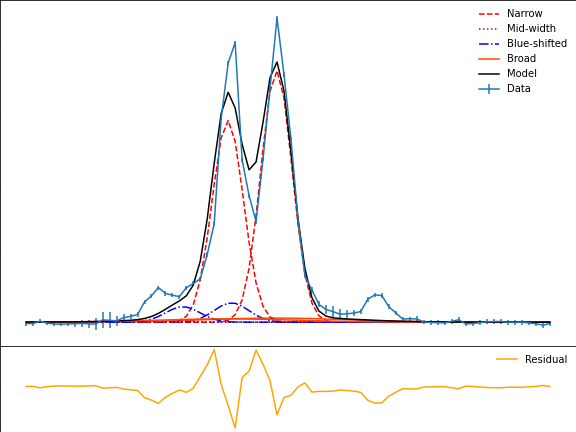

In [59]:
# Search for good initial guess
%matplotlib widget
fig = plt.figure(1)
fig.set_size_inches(8, 6)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))
ax.errorbar(wl_oii3, flux_oii3, noise_oii3, markersize=2, label='Data')

oii3a_nar = gaussian(wl_oii3, oii3a_nar, oii3a_wav, z=z_ha_nar, sigma=sigma_ha_nar)
oii3a_mid = gaussian(wl_oii3, oii3a_mid, oii3a_wav, z=z_ha_mid, sigma=sigma_ha_mid)
oii3a_out = gaussian(wl_oii3, oii3a_out, oii3a_wav, z=z_ha_out, sigma=sigma_ha_out)
oii3a_brd = gaussian(wl_oii3, oii3a_brd, oii3a_wav, z=z_ha_brd, sigma=sigma_ha_brd)

oii3b_nar = gaussian(wl_oii3, oii3b_nar, oii3b_wav, z=z_ha_nar, sigma=sigma_ha_nar)
oii3b_mid = gaussian(wl_oii3, oii3b_mid, oii3b_wav, z=z_ha_mid, sigma=sigma_ha_mid)
oii3b_out = gaussian(wl_oii3, oii3b_out, oii3b_wav, z=z_ha_out, sigma=sigma_ha_out)
oii3b_brd = gaussian(wl_oii3, oii3b_brd, oii3b_wav, z=z_ha_brd, sigma=sigma_ha_brd)

# total
oii3b = oii3b_nar + oii3b_mid + oii3b_out + oii3b_brd
oii3a = oii3a_nar + oii3a_mid + oii3a_out + oii3a_brd

ax.plot(wl_oii3, oii3a_nar, color='red', ls='--', label='Narrow')
ax.plot(wl_oii3, oii3a_mid, color='purple', ls=':', label='Mid-width')
ax.plot(wl_oii3, oii3a_out, color='blue', ls='-.', label='Blue-shifted')
ax.plot(wl_oii3, oii3a_brd, color='orangered', label='Broad')

ax.plot(wl_oii3, oii3b_nar, color='red', ls='--')
ax.plot(wl_oii3, oii3b_mid, color='purple', ls=':')
ax.plot(wl_oii3, oii3b_out, color='blue', ls='-.')
ax.plot(wl_oii3, oii3b_brd, color='orangered')

ax.plot(wl_oii3, oii3b + oii3a, color='black', label='Model')
ax1.plot(wl_oii3, oii3b + oii3a - flux_oii3, color='orange', label='Residual')
ax.legend(frameon=False)
ax1.legend(frameon=False)
#plt.savefig('4compfit_oii37.png', bbox_inches='tight', facecolor='white')

# High ionization lines

## [OIII]$\lambda$5007

# Two component run

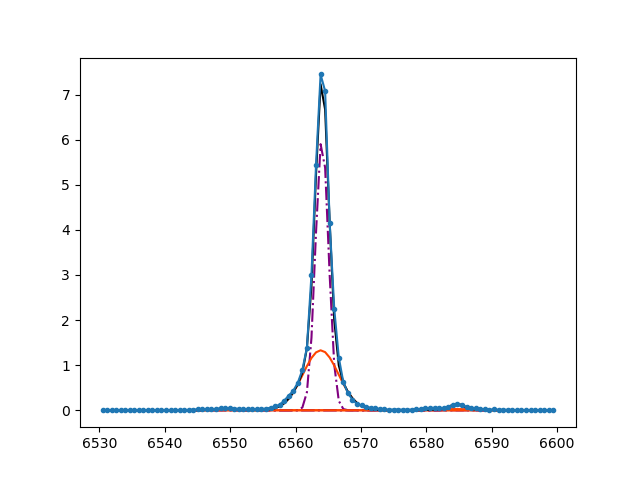

In [5]:
# Search for good initial guess
%matplotlib widget
plt.errorbar(wl_ha, flux_ha, noise_ha,
             marker='o', markersize=3, label='data')

# air
ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

# narrow and broad
ha_nar = gaussian(wl_ha, 15, ha_wav, z=1.89e-04, sigma=0.99)
ha_brd = gaussian(wl_ha, 9, ha_wav, z=1.59e-04, sigma=2.7)

niib_nar = gaussian(wl_ha, 5/50, niib_wav, z=1.89e-04, sigma=0.99)
niib_brd = gaussian(wl_ha, 3/50, niib_wav, z=1.59e-04, sigma=2.7)

niia_nar = gaussian(wl_ha, 15/50, niia_wav, z=1.89e-04, sigma=0.99)
niia_brd = gaussian(wl_ha, 9/50, niia_wav, z=1.59e-04, sigma=2.7)

# total
ha = ha_nar + ha_brd
niib = niib_nar + niib_brd
niia = niia_nar + niia_brd

plt.plot(wl_ha, ha_nar, color='purple', ls='-.')
plt.plot(wl_ha, ha_brd, color='orangered')

plt.plot(wl_ha, niib_nar, color='purple', ls='-.')
plt.plot(wl_ha, niib_brd, color='orangered')

plt.plot(wl_ha, niia_nar, color='purple', ls='-.')
plt.plot(wl_ha, niia_brd, color='orangered')

plt.plot(wl_ha, niib + ha + niia, color='black')

In [6]:
params2_ha_nii = Parameters()

params2_ha_nii.add('z_nar', value=1.89e-4)
params2_ha_nii.add('z_brd', value=1.59e-4)
params2_ha_nii.add('sigma_nar', value=0.99, min=0.)
params2_ha_nii.add('sigma_brd', value=2.7, min=0.)
params2_ha_nii.add('Ha_nar', value=15, min=0.)
params2_ha_nii.add('Ha_brd', value=9, min=0.)
params2_ha_nii.add('Niia_nar', value=0.3, min=0.)
params2_ha_nii.add('Niia_brd', value=0.2, min=0.)
params2_ha_nii.add('Niib_to_niia', value=1/3, vary=False)


def residual2_ha_nii(params2_ha_nii, x, data, uncertainty):
    ha_wav = 6562.801
    niib_wav = 6548.05
    niia_wav = 6583.45
    
    z_nar = params2_ha_nii['z_nar']
    z_brd = params2_ha_nii['z_brd']
    sigma_nar = params2_ha_nii['sigma_nar']
    sigma_brd = params2_ha_nii['sigma_brd']
    ha_nar = params2_ha_nii['Ha_nar']
    ha_brd = params2_ha_nii['Ha_brd']
    niia_nar = params2_ha_nii['Niia_nar']
    niia_brd = params2_ha_nii['Niia_brd']
    niib_nar = params2_ha_nii['Niia_nar']*params2_ha_nii['Niib_to_niia']
    niib_brd = params2_ha_nii['Niia_brd']*params2_ha_nii['Niib_to_niia']
    
    x = wl_ha
    
    model_ha = gaussian(x, ha_nar, ha_wav, z_nar, sigma_nar) \
             + gaussian(x, ha_brd, ha_wav, z_brd, sigma_brd)
    model_niia = gaussian(x, niia_nar, niia_wav, z_nar, sigma_nar) \
               + gaussian(x, niia_brd, niia_wav, z_brd, sigma_brd)
    model_niib = gaussian(x, niib_nar, niib_wav, z_nar, sigma_nar) \
               + gaussian(x, niib_brd, niib_wav, z_brd, sigma_brd)
    model = model_niib + model_ha + model_niia
    return (model - flux_ha) / noise_ha

In [7]:
n_params2_ha_nii = 9
out2_ha_nii = minimize(residual2_ha_nii, params2_ha_nii, args=(1, 1, 1),
                      method='emcee', burn=1200, steps=3000, thin=10,
                      workers=12, nwalkers=n_params2_ha_nii*9, seed=1)

100%|███████████████████████████████████████| 3000/3000 [00:31<00:00, 95.13it/s]


The chain is shorter than 50 times the integrated autocorrelation time for 4 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 60;
tau: [ 35.02374982  43.54854498  74.39655735  27.98451355  53.896916
  61.79401004 282.76443084 281.70574515]


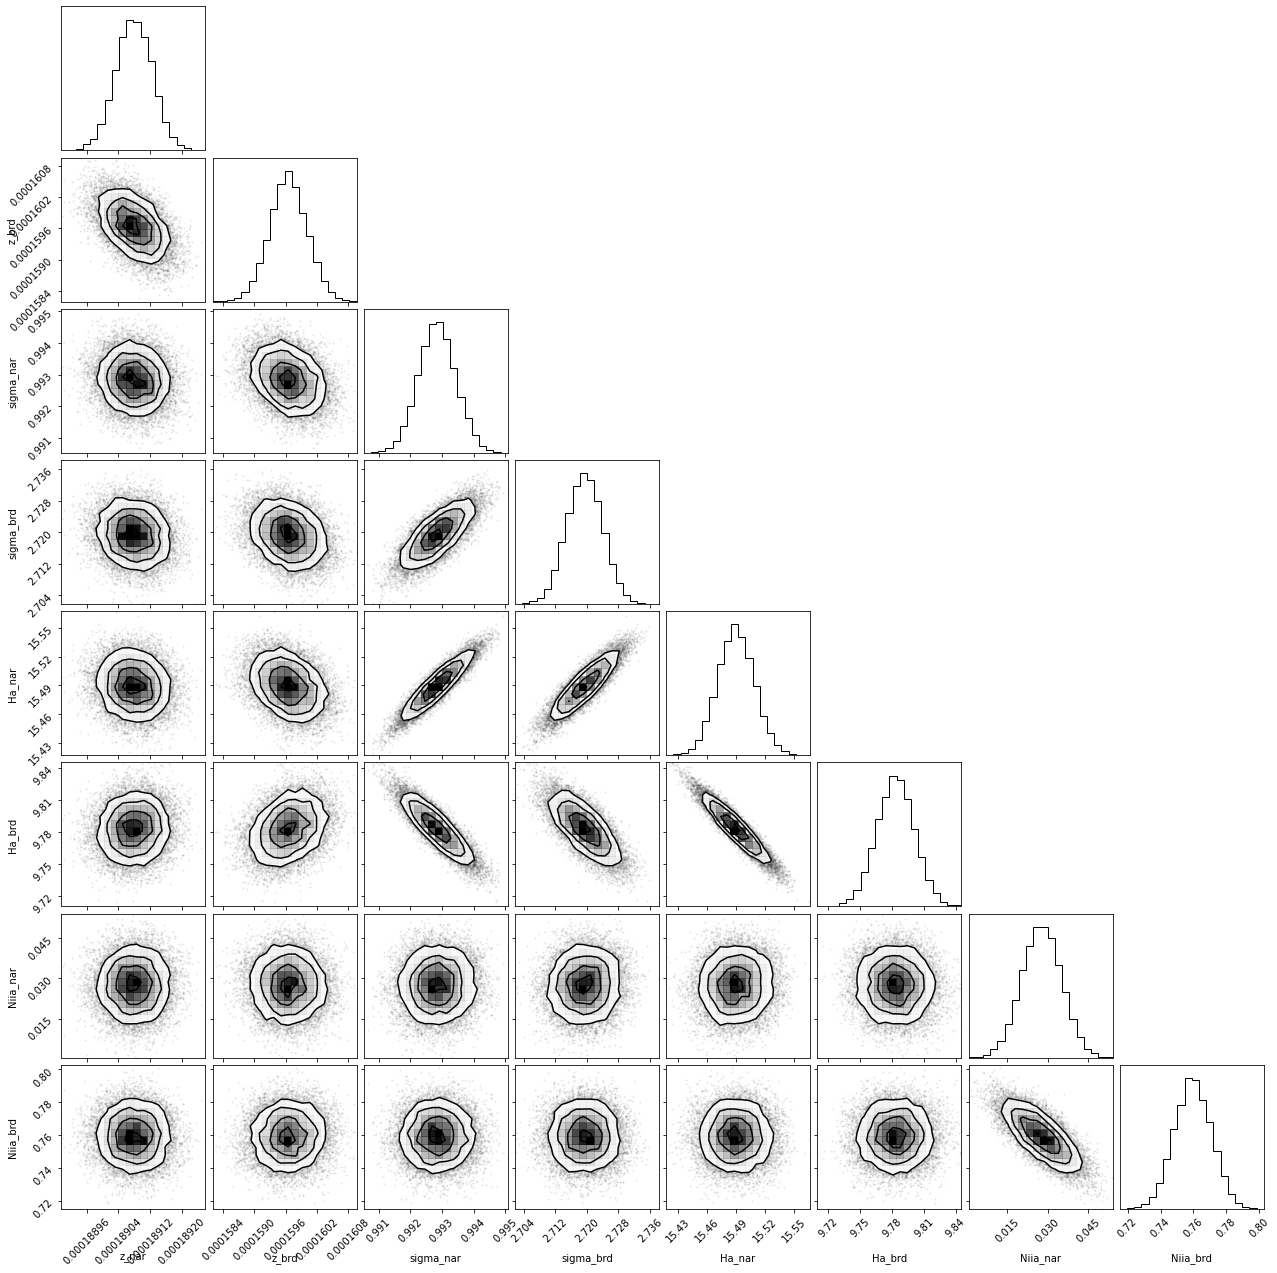

In [8]:
%matplotlib inline
corner.corner(out2_ha_nii.flatchain, labels=out2_ha_nii.var_names);

In [9]:
out2_ha_nii

In [16]:
import uncertainties.umath as uum
from uncertainties import ufloat
from uncertainties import unumpy

ha_nar = out2_ha_nii.flatchain.Ha_nar.mean()
ha_nar_std = out2_ha_nii.flatchain.Ha_nar.std()
ha_brd = out2_ha_nii.flatchain.Ha_brd.mean()
ha_brd_std = out2_ha_nii.flatchain.Ha_brd.std()

niia_nar = out2_ha_nii.flatchain.Niia_nar.mean()
niia_nar_std = out2_ha_nii.flatchain.Niia_nar.std()
niia_brd = out2_ha_nii.flatchain.Niia_brd.mean()
niia_brd_std = out2_ha_nii.flatchain.Niia_brd.std()

ha_nar = ufloat(ha_nar, ha_nar_std)*1e-14
ha_brd = ufloat(ha_brd, ha_brd_std)*1e-14
niia_nar = ufloat(niia_nar, niia_nar_std)*1e-14
niia_brd = ufloat(niia_brd, niia_brd_std)*1e-14

print(ha_nar + ha_brd)
print(niia_nar + niia_brd)

(2.5273+/-0.0026)e-13
(7.87+/-0.13)e-15


ha_one_model = 2.4717e-13 +/- 0.0035e-13
ha_two_model = 2.5273e-13 +/- 0.0026e-13
ha_three_model = 2.542e-13 +/- 0.016e-13

niia_one_model = 4.604e-15 +/- 0.063e-15
niia_two_model = 7.87e-15 +/- 0.13e-15
niia_three_model = 8.05e-15 +/- 0.12e-15

ha_nar_flux, error:  [1.54897771e-13 1.90010449e-16]
ha_brd_flux, error:  [9.78332944e-14 1.77788356e-16]
niia_nar_flux, error:  [2.75698358e-16 7.39023729e-17]
niia_brd_flux, error:  [7.59511375e-15 1.12239241e-16]


(6530.0, 6600.0)

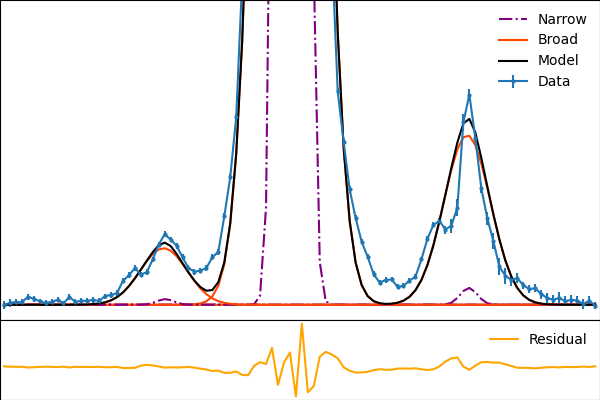

In [13]:
ha_nar = out2_ha_nii.flatchain.Ha_nar.mean()
ha_nar_std = out2_ha_nii.flatchain.Ha_nar.std()
ha_brd = out2_ha_nii.flatchain.Ha_brd.mean()
ha_brd_std = out2_ha_nii.flatchain.Ha_brd.std()

niia_nar = out2_ha_nii.flatchain.Niia_nar.mean()
niia_nar_std = out2_ha_nii.flatchain.Niia_nar.std()
niia_brd = out2_ha_nii.flatchain.Niia_brd.mean()
niia_brd_std = out2_ha_nii.flatchain.Niia_brd.std()

print('ha_nar_flux, error: ', np.array([ha_nar, ha_nar_std])*1e-14)
print('ha_brd_flux, error: ', np.array([ha_brd, ha_brd_std])*1e-14)

print('niia_nar_flux, error: ', np.array([niia_nar, niia_nar_std])*1e-14)
print('niia_brd_flux, error: ', np.array([niia_brd, niia_brd_std])*1e-14)

niib_nar = out2_ha_nii.flatchain.Niia_nar.mean()/3
niib_brd = out2_ha_nii.flatchain.Niia_brd.mean()/3

z_ha_nar = out2_ha_nii.flatchain.z_nar.mean()
z_ha_brd = out2_ha_nii.flatchain.z_brd.mean()
sigma_ha_nar = out2_ha_nii.flatchain.sigma_nar.mean()
sigma_ha_brd = out2_ha_nii.flatchain.sigma_brd.mean()



# Search for good initial guess
%matplotlib widget
fig = plt.figure(1)
fig.set_size_inches(6, 4)
ax = fig.add_axes((0, .2, 1, .8))
ax1 = fig.add_axes((0, 0, 1, .2))
ax.errorbar(wl_ha, flux_ha, noise_ha, marker='.', markersize=4, label='Data')

ha_wav = 6562.801
niib_wav = 6548.05
niia_wav = 6583.45

niib_nar = gaussian(wl_ha, niib_nar, niib_wav, z=z_ha_nar, sigma=sigma_ha_nar)
niib_brd = gaussian(wl_ha, niib_brd, niib_wav, z=z_ha_brd, sigma=sigma_ha_brd)

ha_nar = gaussian(wl_ha, ha_nar, ha_wav, z=z_ha_nar, sigma=sigma_ha_nar)
ha_brd = gaussian(wl_ha, ha_brd, ha_wav, z=z_ha_brd, sigma=sigma_ha_brd)

niia_nar = gaussian(wl_ha, niia_nar, niia_wav, z=z_ha_nar, sigma=sigma_ha_nar)
niia_brd = gaussian(wl_ha, niia_brd, niia_wav, z=z_ha_brd, sigma=sigma_ha_brd)

ha = ha_nar + ha_brd
niia = niia_nar + niia_brd
niib = niib_nar + niib_brd

ax.plot(wl_ha, ha_nar, color='purple', ls='-.', label='Narrow')
ax.plot(wl_ha, ha_brd, color='orangered', label='Broad')
ax.plot(wl_ha, niia_nar, color='purple', ls='-.')
ax.plot(wl_ha, niia_brd, color='orangered')
ax.plot(wl_ha, niib_nar, color='purple', ls='-.')
ax.plot(wl_ha, niib_brd, color='orangered')
ax.plot(wl_ha, niib + ha + niia, color='black', label='Model')
ax1.plot(wl_ha, niib + ha + niia - flux_ha, color='orange', label='Residual')
ax.legend(frameon=False)
ax1.legend(frameon=False)
ax.set_ylim(-0.01, 0.2)
ax.set_xticks([])
ax.set_xlim(6530, 6600)
ax1.set_xlim(6530, 6600)
#plt.savefig('2compfit_ha_zoom.png', bbox_inches='tight')